In [6]:
# 단계 1: 폰트 설정 (OS 자동 감지)
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

# 시스템 OS 확인
system_name = platform.system()

if system_name == 'Darwin': # Mac OS
    print('Mac OS에서 실행 중입니다. AppleGothic을 설정합니다.')
    plt.rc('font', family='AppleGothic')
    plt.rcParams['axes.unicode_minus'] = False
elif system_name == 'Windows': # Windows
    print('Windows에서 실행 중입니다. Malgun Gothic을 설정합니다.')
    plt.rc('font', family='Malgun Gothic')
    plt.rcParams['axes.unicode_minus'] = False
else: # Linux / Google Colab (기존 코드 유지)
    print('Linux/Colab 환경입니다. Nanum 폰트를 설치하고 설정합니다.')
    # Colab 여부 확인 (간단히 try-except 또는 라이브러리 확인)
    try:
        import google.colab
        !apt-get -qq -y install fonts-nanum > /dev/null
        fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
        if len(fm.findSystemFonts(fontpaths=[fontpath])) > 0:
            fe = fm.FontEntry(
                fname=fontpath,
                name='NanumGothic')
            fm.fontManager.ttflist.insert(0, fe)
            plt.rcParams.update({'font.size': 18, 'font.family': 'NanumGothic', 'axes.unicode_minus': False})
    except ImportError:
        print('Google Colab이 아닙니다. 시스템 기본 폰트를 사용합니다.')


Mac OS에서 실행 중입니다. AppleGothic을 설정합니다.


In [18]:
# 데이터 직접 로드 (파일 업로드 위젯 대체)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 분석에 사용할 파일명 (위치 기반 날씨 병합 데이터)
filename = 'merged_subway_weather_final.csv'

# 1. 현재 디렉토리에서 찾기
file_path = filename

# 2. 없으면 절대 경로 시도 (로컬 환경 대응)
if not os.path.exists(file_path):
    file_path = f'/Users/minjae/Downloads/프로젝트/Transporation/content/{filename}'

if os.path.exists(file_path):
    print(f"파일을 로드합니다: {file_path}")
    df = pd.read_csv(file_path)
    print(f"데이터 크기: {df.shape}")
    print("데이터 미리보기:")
    display(df.head())
else:
    print(f"파일을 찾을 수 없습니다: {filename}")
    df = pd.DataFrame()


파일을 로드합니다: merged_subway_weather_final.csv
데이터 크기: (29774986, 10)
데이터 미리보기:


,날짜,호선,역번호,역명,구분,시간대_raw,승객수,시간,기온,시간누적강우량
0,2024-01-01,1호선,150,서울역,승차,06시 이전,383,5,-1.4,0.0
1,2024-01-01,1호선,150,서울역,승차,06시 이전,383,5,0.1,0.0
2,2024-01-01,1호선,150,서울역,승차,06시 이전,383,5,0.9,0.0
3,2024-01-01,1호선,150,서울역,승차,06시 이전,383,5,-1.0,0.0
4,2024-01-01,1호선,150,서울역,승차,06시 이전,383,5,-1.4,0.0


/var/folders/nz/37j7ff7d031_bdbf2_jwxxy00000gn/T/ipykernel_21743/1759867628.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=line_counts.index, y=line_counts.values, palette='viridis')


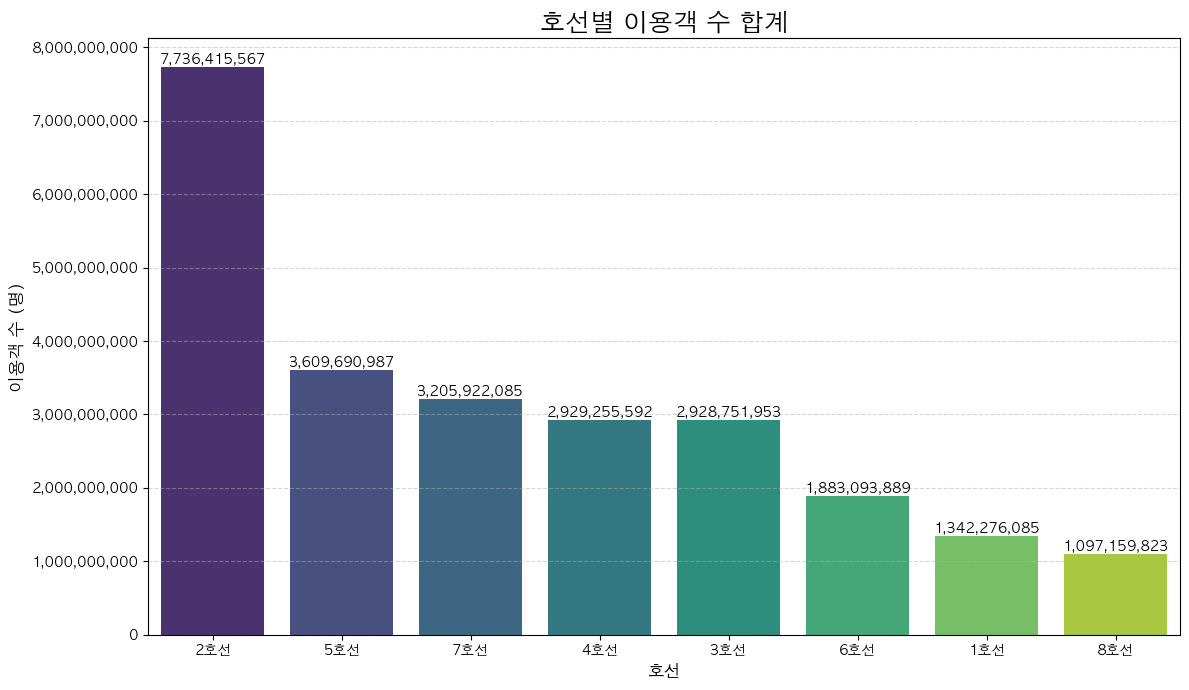

In [ ]:
# 1. 2024년 호선별 이용객 수 합계

import matplotlib.ticker as ticker

# 승객수 컬럼을 숫자로 확실히 변환
df['승객수'] = pd.to_numeric(df['승객수'], errors='coerce').fillna(0)

# 호선별 이용객 수 집계
line_counts = df.groupby('호선')['승객수'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
ax = sns.barplot(x=line_counts.index, y=line_counts.values, palette='viridis')

plt.title('2024년 호선별 이용객 수 합계', fontsize=18, fontweight='bold')
plt.xlabel('호선', fontsize=12)
plt.ylabel('이용객 수 (명)', fontsize=12)

# Y축 천 단위 구분
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))

# 막대 위에 숫자 표시
for i, v in enumerate(line_counts.values):
    plt.text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

/var/folders/nz/37j7ff7d031_bdbf2_jwxxy00000gn/T/ipykernel_21743/3801260599.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=station_counts.values, y=station_counts.index, palette='rocket', orient='h')


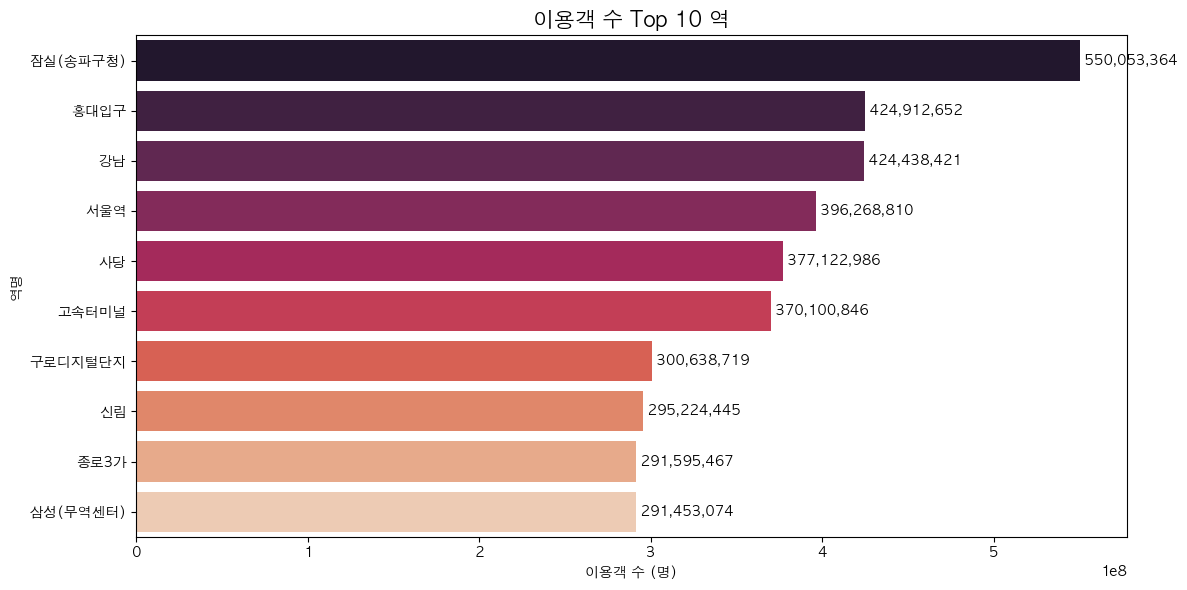

In [ ]:
# 2. 역별 이용객 수 집계 후 상위 10개
station_counts = df.groupby('역명')['승객수'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=station_counts.values, y=station_counts.index, palette='rocket', orient='h')

plt.title('2024년 이용객 수 Top 10', fontsize=15, fontweight='bold')
plt.xlabel('이용객 수 (명)')
plt.ylabel('역명')

# 막대 옆에 수치 표시
for i, v in enumerate(station_counts.values):
    plt.text(v, i, f' {v:,.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

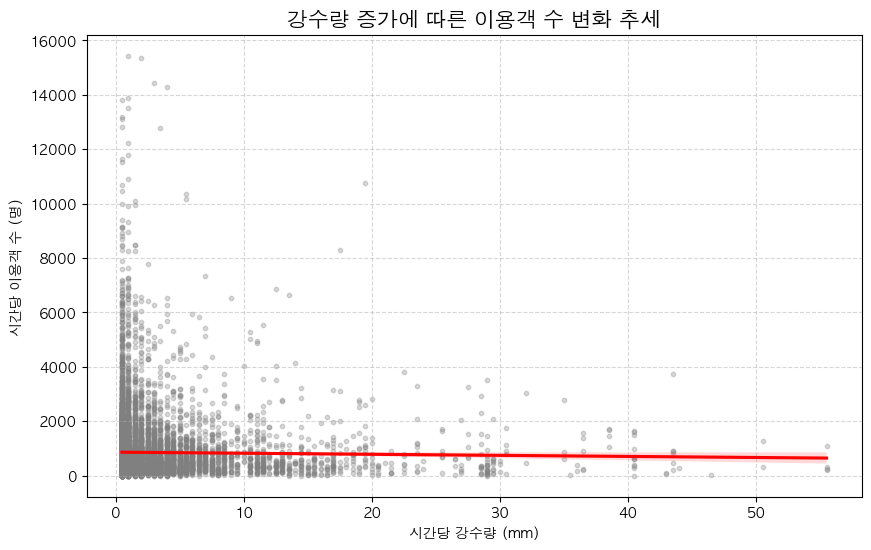

In [ ]:
# 3. 강수량과 이용객 수의 상관관계

if '시간누적강우량' in df.columns:
    # 비가 온 데이터만 추출
    rain_df = df[df['시간누적강우량'] > 0]

    # 1만개 샘플링
    if len(rain_df) > 10000:
        rain_sample = rain_df.sample(n=10000, random_state=42)
    else:
        rain_sample = rain_df

    plt.figure(figsize=(10, 6))

    sns.regplot(data=rain_sample, x='시간누적강우량', y='승객수', 
                scatter_kws={'alpha' : 0.3, 's' : 10, 'color' : 'gray'}, 
                line_kws={'color' : 'red'})

    plt.title('2024년 강수량 증가에 따른 이용객 수 변화 추세', fontsize=15, fontweight='bold')
    plt.xlabel('시간당 강수량 (mm)')
    plt.ylabel('시간당 이용객 수 (명)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
else:
    print("'시간누적강우량' 컬럼이 없어 그래프를 그릴 수 없습니다.")

/var/folders/nz/37j7ff7d031_bdbf2_jwxxy00000gn/T/ipykernel_21743/2702117335.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='날씨상태', y='승객수',


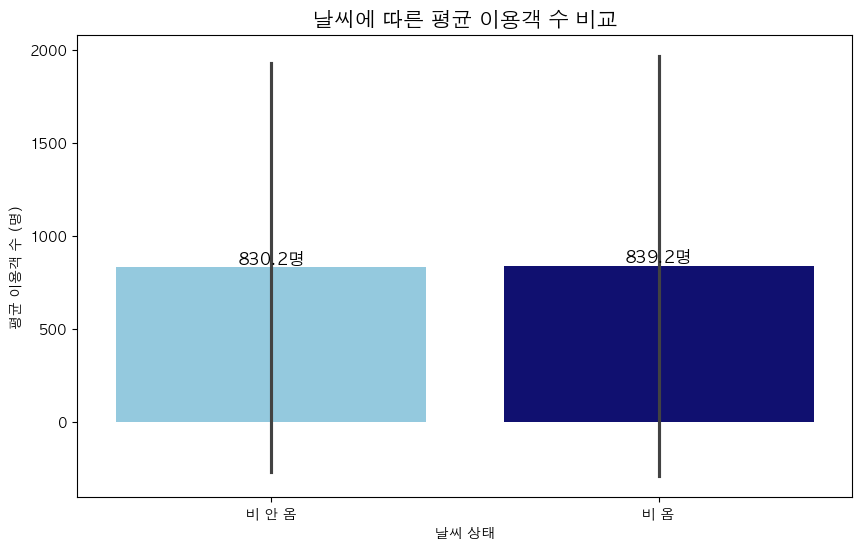

[평균 이용객 수]
비 안 옴: 830.2명
비 옴:   839.2명


In [ ]:
# 4. 강수 여부에 따른 이용객 수 비교
if '시간누적강우량' in df.columns:

    df['날씨상태'] = df['시간누적강우량'].apply(lambda x: '비 옴' if x > 0 else '비 안 옴')

    plt.figure(figsize=(10, 6))

    # 평균 이용객 수 비교
    ax = sns.barplot(data=df, x='날씨상태', y='승객수', 
                     palette={'비 옴' : 'navy', '비 안 옴' : 'skyblue'}, 
                     errorbar='sd')

    plt.title('날씨에 따른 평균 이용객 수 비교', fontsize=15, fontweight='bold')
    plt.xlabel('날씨 상태')
    plt.ylabel('평균 이용객 수 (명)')

    # 막대 위에 수치 표시
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.text(p.get_x() + p.get_width() / 2., height, 
                    f'{height:,.1f}명', 
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.show()

    avg_stats = df.groupby('날씨상태')['승객수'].mean()
    print("[평균 이용객 수]")
    print(f"비 안 옴 : {avg_stats['비 안 옴']:,.1f}명")
    print(f"비 옴 :   {avg_stats['비 옴']:,.1f}명")
else:
    print("'시간누적강우량' 컬럼이 없어 그래프를 그릴 수 없습니다.")